# Logistic Regression Demo with Gradient Ascent


We study fitting the logistic regression model with gradient ascent. In logistic regression we observe data $(x_i,y_i)$ where the $x_i \in \mathbb{R}^p$ are known as predictors, features, or attributes. The response $y_i \in \{0,1\}$ is binary. We would like to know how $x$ affects $y$. For example, does $y$ tend to be $1$ when certain elements of $x$ are large?

In such cases it is not appropriate to model $y$ as a linear function of $x$ because a linear function will make predictions outside of the interval $[0,1]$. Instead we can model $y_i \sim Bernoulli(p_i)$. In other words $P(Y_i = 1) = p_i$ and $P(Y_i = 0) = 1-p_i$. We then relate the $p_i$ to the $x_i$ through the logistic function

$$ p_i = \frac{1}{1 + e^{-x_i^T\beta}}$$

In this Equation $\beta$ is unknown. We estimate it from the data. $p_i$ is also unknown. Once we have an estimate of $\beta$, we can use it to produce an estimate of $p_i$. There are many other possible forms of the equation for linking the $x_i$ with $p_i$, but the logistic function is the most common.

See [Logistic Regression](https://en.wikipedia.org/wiki/Logistic_regression) or Chapter 14 of Lange for more background on logistic regression.

We begin by simulating some data from the model. We consider a 1-dimensional case with an intercept, so $p=2$.

In [1]:
import numpy as np
n = 200
x = np.linspace(-5,5,num=n)
beta = np.array([2.,1.])

In [2]:
## computes the p_i for any x_i and beta
def logistic(x, beta):
    return( 1 / (1+np.exp(-np.sum(x*beta))))

In [3]:
## the design matrix, we have one parameter for each column of X
X = np.column_stack((np.ones(n),x))

In [4]:
## p_i vector
p = np.apply_along_axis(lambda y: logistic(y,beta),1,X)

In [5]:
## simulate responses
rng = np.random.default_rng(1234)
y = rng.binomial(n=1,p=p)

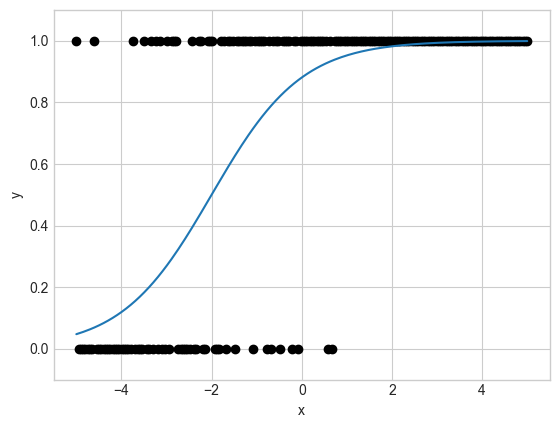

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

plt.plot(x,y,'o',color='black')
plt.plot(x,p)
plt.xlabel("x")
plt.ylabel("y")
plt.ylim(-.1,1.1);

## Log Likelihood Contours

We will maximize the logistic log likelihood. The likelihood is
\begin{align*}
L(\beta|X,Y) &= \prod_{i=1}^n f(y_i|\beta,x_i)\\
&= \prod_{i=1}^n p_i^{y_i}(1-p_i)^{1-y_i}
\end{align*}

So the log likelihood is
$$ \log L(\beta|X,Y) = \sum_{i=1}^n \left(y_i \log p_i + (1-y_i)\log(1-p_i)\right)$$

Before we find the $\beta$ which maximizes $\log L$, we first plot the contours.

In [7]:
def logistic_loglik(beta, X, y):
    p = np.apply_along_axis(lambda z: logistic(z, beta), 1, X)
    return np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))

In [8]:
## use meshgrid function for producing grid as input for contour plot
beta1g = np.linspace(-1.0,5.0,100)
beta2g = np.linspace(-1.0,3.0,100)

In [9]:
beta1g, beta2g = np.meshgrid(beta1g, beta2g)
beta1g.shape

(100, 100)

In [10]:
# All pairs in grid
XYpairs = np.vstack([ beta1g.reshape(-1), beta2g.reshape(-1) ])
XYpairs

array([[-1.        , -0.93939394, -0.87878788, ...,  4.87878788,
         4.93939394,  5.        ],
       [-1.        , -1.        , -1.        , ...,  3.        ,
         3.        ,  3.        ]], shape=(2, 10000))

In [11]:
loglik = np.apply_along_axis(lambda z: logistic_loglik(z, X, y), 0, XYpairs)
loglik = loglik.reshape((100, 100))

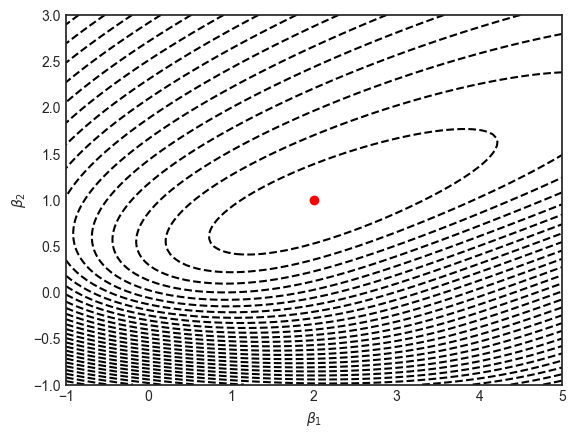

In [12]:
# plot contours
plt.style.use('seaborn-v0_8-white')
plt.contour(beta1g, beta2g, loglik, 30, colors='black');
plt.plot(beta[0],beta[1],'o',color='red');
plt.xlabel(r'$\beta_1$')
plt.ylabel(r'$\beta_2$');

## Fit with Gradient Ascent

Fit logistic model with gradient ascent and step halving. We start by computing the gradient of the log likelihood.

$$\frac{d\log L(\beta|X,Y)}{d\beta} = \sum_{i=1}^n \underbrace{\left(\frac{y_i}{p_i} - \frac{1-y_i}{1-p_i}\right)}_{\equiv t_i}\frac{dp_i}{d\beta}$$

and

$$ \frac{dp_i}{d\beta} = \underbrace{(1+e^{-x_i^T\beta})^{-2}e^{-x_i^T\beta}}_{\equiv s_i}x_i$$

In [18]:
## number of iterations, in practice we stop once converged
Niter = 100
## initial value to start
initial_beta = np.zeros(2)
## store iterations
beta_hat = np.zeros((Niter + 1, initial_beta.shape[0]))
beta_hat[0,:] = initial_beta
for ii in np.arange(Niter):
    pre = np.apply_along_axis(lambda z: np.exp(-np.sum(z * beta_hat[ii,:])), 1, X)
    ## Here, compute the gradient of the logistic log-likelihood
    p = 1 / (1 + pre)
    s = ( p ** 2 ) * pre 
    t = y/p - ((1-y) / (1-p))
    logLgrad = np.sum(X * (s * t)[:, np.newaxis], axis=0)
    half = True
    while half:
        temp = beta_hat[ii,:] + logLgrad
        newlik = logistic_loglik(temp, X, y)
        ## for temp far from maximum, logit_loglik may return
        ## Nan values. we replace these with -Inf log likelihoods
        if np.isnan(newlik):
            newlik = -np.inf
        ## if less likely, halve step size
        if (newlik < logistic_loglik(beta_hat[ii,:], X, y)):
            logLgrad = logLgrad / 2
        else:
            half = False
    beta_hat[ii+1,:] = temp

/var/folders/51/zpgx0xr16vj__n700wy9_16r0000gn/T/ipykernel_3870/1822085453.py:3: RuntimeWarning: overflow encountered in exp
  return( 1 / (1+np.exp(-np.sum(x*beta))))
/var/folders/51/zpgx0xr16vj__n700wy9_16r0000gn/T/ipykernel_3870/3661114034.py:3: RuntimeWarning: divide by zero encountered in log
  return np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
/var/folders/51/zpgx0xr16vj__n700wy9_16r0000gn/T/ipykernel_3870/3661114034.py:3: RuntimeWarning: invalid value encountered in multiply
  return np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))


In [15]:
beta_hat

array([[0.        , 0.        ],
       [0.3359375 , 1.34991363],
       [0.93061136, 0.41102469],
       [1.0015338 , 0.76734439],
       [1.28712515, 0.51097341],
       [1.29966899, 0.79600756],
       [1.48731698, 0.61937447],
       [1.4925244 , 0.80168854],
       [1.61352258, 0.71454244],
       [1.62541538, 0.80856176],
       [1.78085141, 0.75643038],
       [1.77559221, 0.85280245],
       [1.82771583, 0.8215106 ],
       [1.84297547, 0.89009691],
       [1.86885145, 0.85620028],
       [1.96068286, 0.92756752],
       [1.9786653 , 0.89106234],
       [1.99550834, 0.91386632],
       [2.00395716, 0.90122568],
       [2.03015623, 0.92412024],
       [2.03623357, 0.91155695],
       [2.04149057, 0.91978595],
       [2.0444835 , 0.91502254],
       [2.04877454, 0.91908023],
       [2.05204567, 0.9154173 ],
       [2.05204918, 0.91833846],
       [2.05921427, 0.91773437],
       [2.05880072, 0.92046758],
       [2.06074609, 0.91969214],
       [2.06069095, 0.92088545],
       [2.

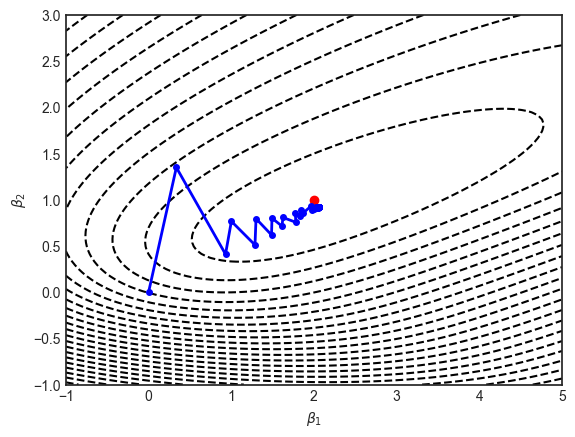

In [19]:
# path of the gradient ascent algorith
plt.style.use('seaborn-v0_8-white')
plt.contour(beta1g, beta2g, loglik, 25, colors='black');
plt.plot(beta[0],beta[1],'o',color='red');
plt.xlabel(r'$\beta_1$')
plt.ylabel(r'$\beta_2$');
plt.plot(beta_hat[:, 0], beta_hat[:, 1], '-o', color='blue', linewidth=2, markersize=4, label='Gradient Ascent Path')

**Exercise**: Try starting the ascent algorithm at different initial values and graphically monitor convergence.

**Exercise**: Try implementing an automatic stopping strategy so that when the parameter estimates do not change much after an iteration, the algorithm stops.


/var/folders/51/zpgx0xr16vj__n700wy9_16r0000gn/T/ipykernel_3870/1822085453.py:3: RuntimeWarning: overflow encountered in exp
  return( 1 / (1+np.exp(-np.sum(x*beta))))
/var/folders/51/zpgx0xr16vj__n700wy9_16r0000gn/T/ipykernel_3870/3661114034.py:3: RuntimeWarning: divide by zero encountered in log
  return np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
/var/folders/51/zpgx0xr16vj__n700wy9_16r0000gn/T/ipykernel_3870/3661114034.py:3: RuntimeWarning: invalid value encountered in multiply
  return np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))


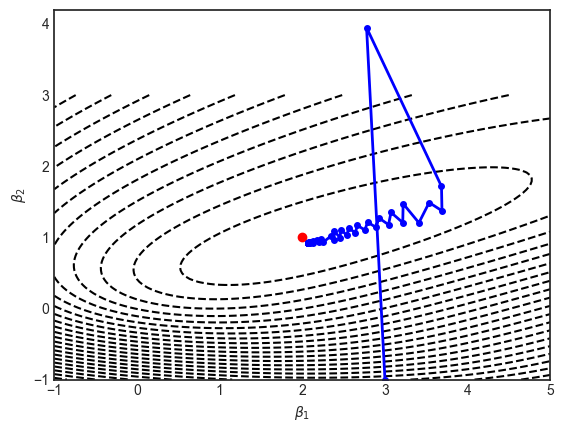

In [23]:
## number of iterations, in practice we stop once converged
Niter = 100
## initial value to start
initial_beta = np.array([3,-1])
## store iterations
beta_hat = np.zeros((Niter + 1, initial_beta.shape[0]))
beta_hat[0,:] = initial_beta
for ii in np.arange(Niter):
    pre = np.apply_along_axis(lambda z: np.exp(-np.sum(z * beta_hat[ii,:])), 1, X)
    ## Here, compute the gradient of the logistic log-likelihood
    p = 1 / (1 + pre)
    s = ( p ** 2 ) * pre 
    t = y/p - ((1-y) / (1-p))
    logLgrad = np.sum(X * (s * t)[:, np.newaxis], axis=0)
    half = True
    while half:
        temp = beta_hat[ii,:] + logLgrad
        newlik = logistic_loglik(temp, X, y)
        ## for temp far from maximum, logit_loglik may return
        ## Nan values. we replace these with -Inf log likelihoods
        if np.isnan(newlik):
            newlik = -np.inf
        ## if less likely, halve step size
        if (newlik < logistic_loglik(beta_hat[ii,:], X, y)):
            logLgrad = logLgrad / 2
        else:
            half = False
    beta_hat[ii+1,:] = temp
    

# path of the gradient ascent algorith
plt.style.use('seaborn-v0_8-white')
plt.contour(beta1g, beta2g, loglik, 25, colors='black');
plt.plot(beta[0],beta[1],'o',color='red');
plt.xlabel(r'$\beta_1$')
plt.ylabel(r'$\beta_2$');
plt.plot(beta_hat[:, 0], beta_hat[:, 1], '-o', color='blue', linewidth=2, markersize=4, label='Gradient Ascent Path')

/var/folders/51/zpgx0xr16vj__n700wy9_16r0000gn/T/ipykernel_3870/1822085453.py:3: RuntimeWarning: overflow encountered in exp
  return( 1 / (1+np.exp(-np.sum(x*beta))))
/var/folders/51/zpgx0xr16vj__n700wy9_16r0000gn/T/ipykernel_3870/3661114034.py:3: RuntimeWarning: divide by zero encountered in log
  return np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))
/var/folders/51/zpgx0xr16vj__n700wy9_16r0000gn/T/ipykernel_3870/3661114034.py:3: RuntimeWarning: invalid value encountered in multiply
  return np.sum(y * np.log(p) + (1 - y) * np.log(1 - p))


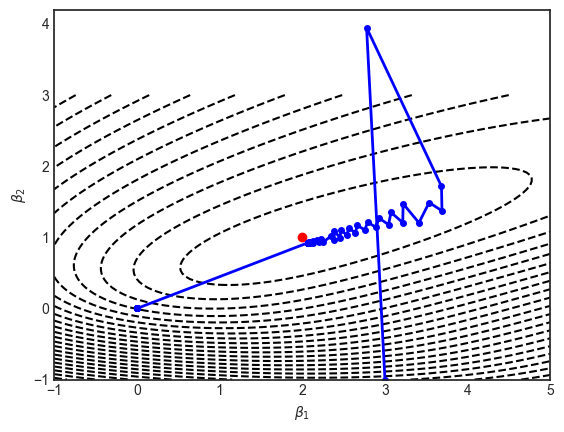

In [25]:
## number of iterations, in practice we stop once converged
Niter = 100
## initial value to start
initial_beta = np.array([3,-1])
## store iterations
beta_hat = np.zeros((Niter + 1, initial_beta.shape[0]))
beta_hat[0,:] = initial_beta
for ii in np.arange(Niter):
    pre = np.apply_along_axis(lambda z: np.exp(-np.sum(z * beta_hat[ii,:])), 1, X)
    ## Here, compute the gradient of the logistic log-likelihood
    p = 1 / (1 + pre)
    s = ( p ** 2 ) * pre 
    t = y/p - ((1-y) / (1-p))
    logLgrad = np.sum(X * (s * t)[:, np.newaxis], axis=0)
    half = True
    while half:
        temp = beta_hat[ii,:] + logLgrad
        newlik = logistic_loglik(temp, X, y)
        ## for temp far from maximum, logit_loglik may return
        ## Nan values. we replace these with -Inf log likelihoods
        if np.isnan(newlik):
            newlik = -np.inf
        ## if less likely, halve step size
        if (newlik < logistic_loglik(beta_hat[ii,:], X, y)):
            logLgrad = logLgrad / 2
        else:
            half = False
            
    if (np.sqrt(np.sum((temp - beta_hat[ii,:])**2)) < 1e-6):
        break 
    beta_hat[ii+1,:] = temp
    

# path of the gradient ascent algorith
plt.style.use('seaborn-v0_8-white')
plt.contour(beta1g, beta2g, loglik, 25, colors='black');
plt.plot(beta[0],beta[1],'o',color='red');
plt.xlabel(r'$\beta_1$')
plt.ylabel(r'$\beta_2$');
plt.plot(beta_hat[:, 0], beta_hat[:, 1], '-o', color='blue', linewidth=2, markersize=4, label='Gradient Ascent Path')

In [26]:
beta_hat

array([[ 3.        , -1.        ],
       [ 2.77750308,  3.94903652],
       [ 3.68386546,  1.71640786],
       [ 3.6896749 ,  1.372923  ],
       [ 3.53487585,  1.48944452],
       [ 3.41069545,  1.20443584],
       [ 3.21980685,  1.47330878],
       [ 3.21533754,  1.20721017],
       [ 3.07349079,  1.35003906],
       [ 3.04304053,  1.17823786],
       [ 2.92626475,  1.27247714],
       [ 2.89056794,  1.14076351],
       [ 2.78995937,  1.21433264],
       [ 2.75657478,  1.10196511],
       [ 2.66753275,  1.16868698],
       [ 2.64021337,  1.06452932],
       [ 2.55963997,  1.13299507],
       [ 2.54067756,  1.02927077],
       [ 2.46588397,  1.10628077],
       [ 2.45705643,  0.99602978],
       [ 2.38522676,  1.08836646],
       [ 2.38833733,  0.96405087],
       [ 2.35226913,  1.0218654 ],
       [ 2.24911252,  0.92850847],
       [ 2.22260122,  0.9795839 ],
       [ 2.19615476,  0.94091515],
       [ 2.18169411,  0.96206304],
       [ 2.13556176,  0.92408693],
       [ 2.12518883,

## Python package `statsmodels`

[statsmodels](http://www.statsmodels.org) has many statistical functions. The function arguments and return values follow R style closely. statsmodels is developed on [github](https://github.com/statsmodels/statsmodels). statsmodels and scipy share many similarities, but statsmodels takes a statistical perspective to models, e.g. models are typically fit with no regularization and functions return parameter uncertainties. Less focus on prediction, more on parameter estimation.

In [ ]:
import statsmodels.api as sm

In [ ]:
results = sm.GLM(y,X,family=sm.families.Binomial()).fit()

In [ ]:
results.params